# Minería de datos - 2027-1
## Licenciatura en Tecnología ENES J - UNAM
## Profesor: Ulises Olivares
### 13 de agosto de 2025


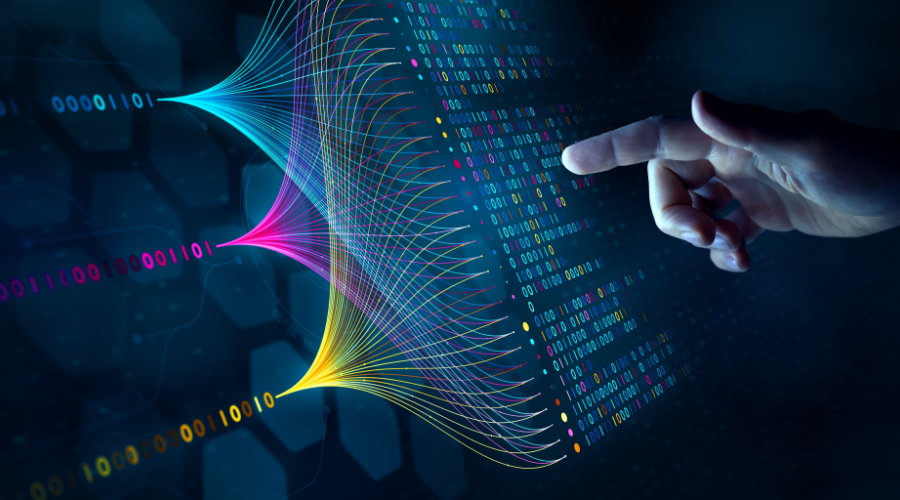


#Análisis exploratorio de datos (EDA)

**tema:** dataset real de diabetes (scikit-learn)  
**objetivo general:** realizar un eda completo y reproducible sobre un conjunto de datos real de salud,
documentando cada decisión para preparar los datos rumbo a un modelo de aprendizaje supervisado de regresión.


## Qué aprenderás
- entender la estructura del dataset y la variable objetivo (progresión de la enfermedad en un año).
- verificar calidad de datos: tipos, valores faltantes, duplicados y outliers.
- calcular y visualizar estadísticas descriptivas y correlaciones.
- documentar hallazgos y proponer mejoras para el preprocesamiento.
- dejar un conjunto de datos listo para modelado básico de regresión.

**dataset:** *diabetes* de `scikit-learn` (datos reales; mediciones clínicas estandarizadas).


## Configuración rápida
ejecuta esta celda primero. si trabajas en colab, `numpy`, `pandas`, `matplotlib` y `scikit-learn` ya deberían estar instaladas.


In [1]:
# configuración básica
import sys, platform, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("versiones → python:", platform.python_version(),
      "| numpy:", np.__version__,
      "| pandas:", pd.__version__)


versiones → python: 3.13.14 | numpy: 2.5.2 | pandas: 3.0.5


## Cargar datos reales
opción a) cargar directamente desde `scikit-learn` (recomendado).  
opción b) cargar desde un archivo `csv` si lo tienes en tu unidad (misma estructura).


In [2]:
# opción a) cargar desde scikit-learn
dataset = load_diabetes(as_frame=True, scaled=False)
df = dataset.frame.copy()
df.rename(columns={"target":"target_disease_progression"}, inplace=True)

feature_names = list(dataset.feature_names)
target_name = "target_disease_progression"

print("forma del dataframe:", df.shape)
df.head()


forma del dataframe: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target_disease_progression
0,59.0000,2.0000,32.1000,101.0000,157.0000,93.2000,38.0000,4.0000,4.8598,87.0000,151.0000
1,48.0000,1.0000,21.6000,87.0000,183.0000,103.2000,70.0000,3.0000,3.8918,69.0000,75.0000
2,72.0000,2.0000,30.5000,93.0000,156.0000,93.6000,41.0000,4.0000,4.6728,85.0000,141.0000
3,24.0000,1.0000,25.3000,84.0000,198.0000,131.4000,40.0000,5.0000,4.8903,89.0000,206.0000
4,50.0000,1.0000,23.0000,101.0000,192.0000,125.4000,52.0000,4.0000,4.2905,80.0000,135.0000


In [3]:
# opción b) (alternativa): cargar un csv si lo subes a colab
# from google.colab import files
# uploaded = files.upload()
# import pandas as pd
# df = pd.read_csv("diabetes_regression.csv")
# df.head()


## Diccionario de datos
características estandarizadas (promedio 0, varianza 1) comunes en el análisis clínico:
- `age`: edad
- `sex`: sexo
- `bmi`: índice de masa corporal
- `bp`: presión arterial media
- `s1` a `s6`: medidas séricas (perfiles lipídicos y glucémicos estandarizados)
- `target_disease_progression`: progresión cuantitativa de la enfermedad en un año (variable objetivo)


## Estructura y tipos de datos
verificamos tipos, memoria usada, valores únicos, duplicados y presencia de nulos.


In [4]:
df.info()
print("\nrecuento de nulos por columna:")
print(df.isna().sum().sort_values(ascending=False))

dups = df.duplicated().sum()
print("\nduplicados exactos:", dups)

print("\nresumen estadístico:")
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         442 non-null    float64
 1   sex                         442 non-null    float64
 2   bmi                         442 non-null    float64
 3   bp                          442 non-null    float64
 4   s1                          442 non-null    float64
 5   s2                          442 non-null    float64
 6   s3                          442 non-null    float64
 7   s4                          442 non-null    float64
 8   s5                          442 non-null    float64
 9   s6                          442 non-null    float64
 10  target_disease_progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

recuento de nulos por columna:
age                           0
sex                           0
bmi                        

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target_disease_progression
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,48.5181,1.4683,26.3758,94.6470,189.1403,115.4391,49.7885,4.0702,4.6414,91.2602,152.1335
std,13.1090,0.4996,4.4181,13.8313,34.6081,30.4131,12.9342,1.2904,0.5224,11.4963,77.0930
min,19.0000,1.0000,18.0000,62.0000,97.0000,41.6000,22.0000,2.0000,3.2581,58.0000,25.0000
25%,38.2500,1.0000,23.2000,84.0000,164.2500,96.0500,40.2500,3.0000,4.2767,83.2500,87.0000
50%,50.0000,1.0000,25.7000,93.0000,186.0000,113.0000,48.0000,4.0000,4.6200,91.0000,140.5000
75%,59.0000,2.0000,29.2750,105.0000,209.7500,134.5000,57.7500,5.0000,4.9972,98.0000,211.5000
max,79.0000,2.0000,42.2000,133.0000,301.0000,242.4000,99.0000,9.0900,6.1070,124.0000,346.0000


## Inspección de la variable objetivo
exploramos la distribución de la progresión y buscamos asimetrías.


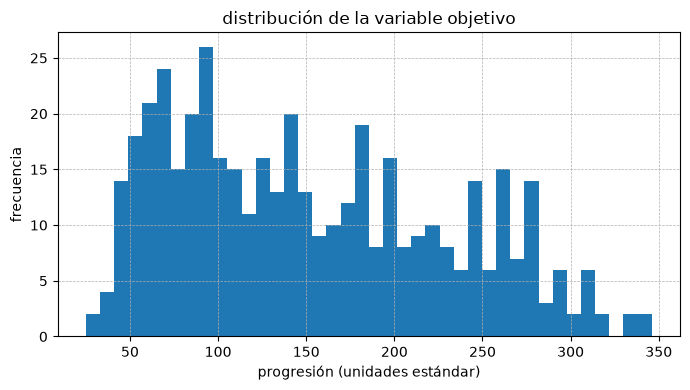

estadísticos de la variable objetivo:
count   442.0000
mean    152.1335
std      77.0930
min      25.0000
25%      87.0000
50%     140.5000
75%     211.5000
max     346.0000
Name: target_disease_progression, dtype: float64


In [5]:
plt.figure(figsize=(7,4))
df['target_disease_progression'].hist(bins=40)
plt.title("distribución de la variable objetivo")
plt.xlabel("progresión (unidades estándar)")
plt.ylabel("frecuencia")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

print("estadísticos de la variable objetivo:")
print(df['target_disease_progression'].describe())


## Visualizaciones univariadas
histogramas y boxplots para un subconjunto de variables clave.


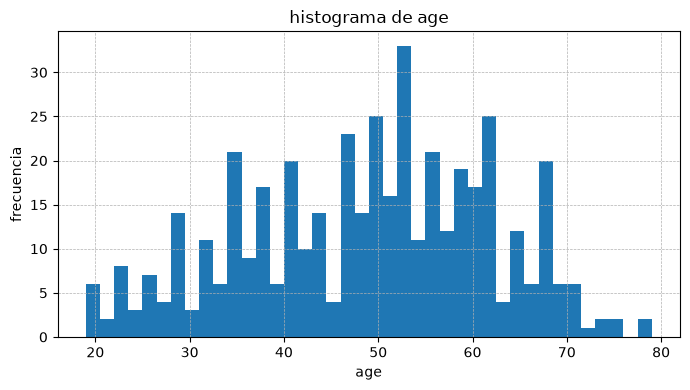

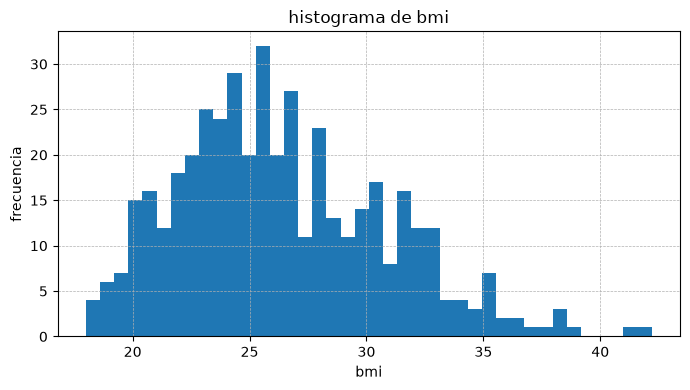

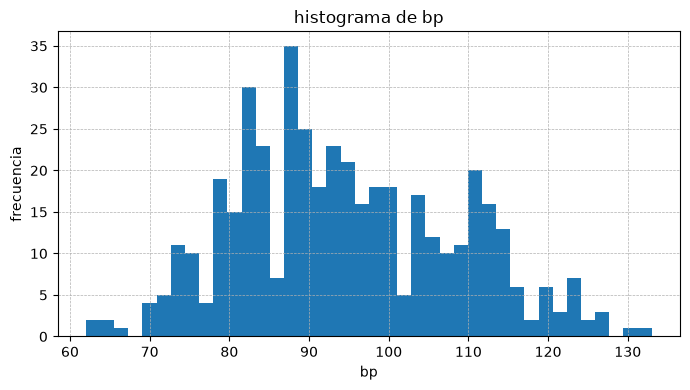

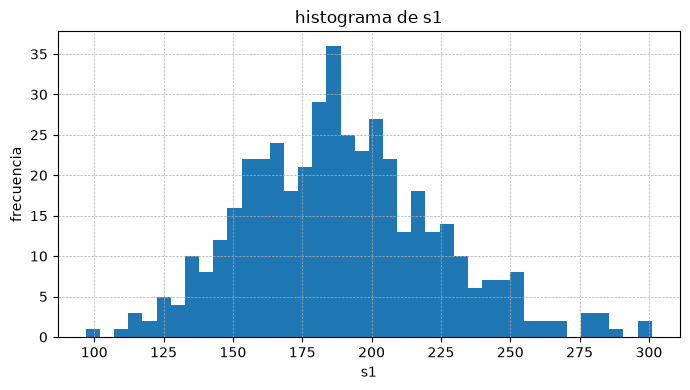

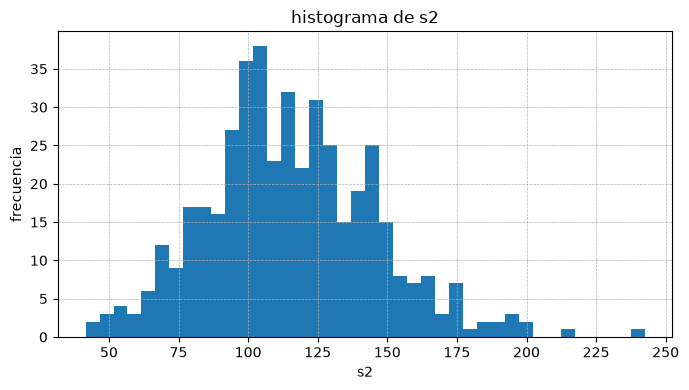

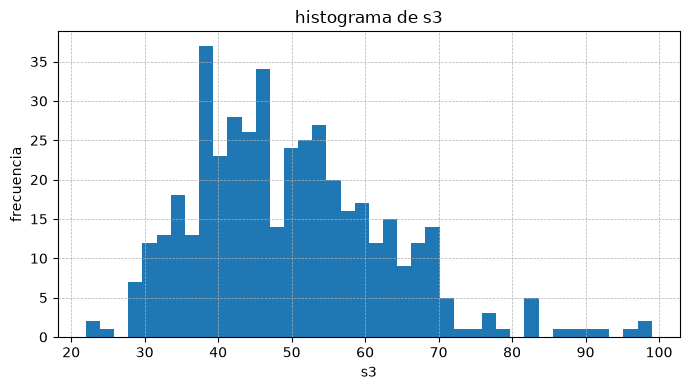

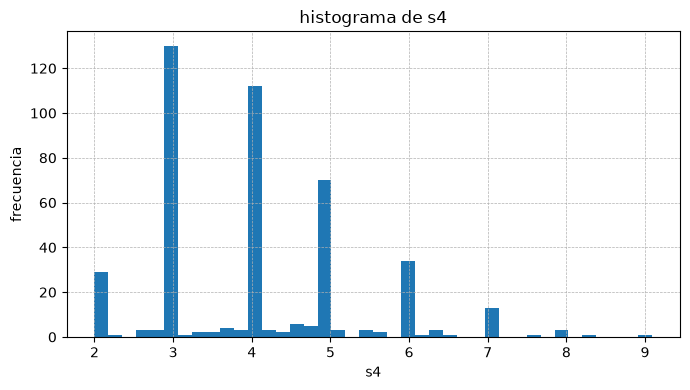

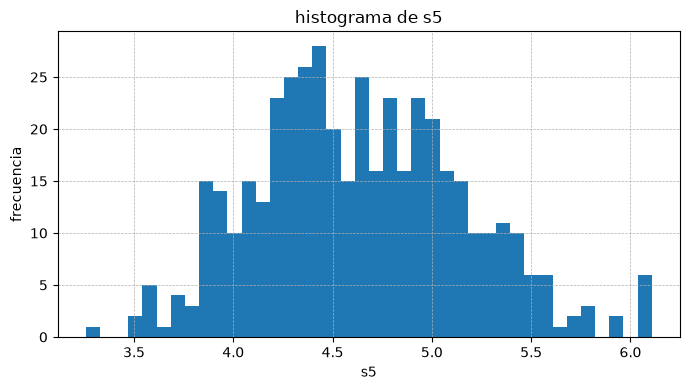

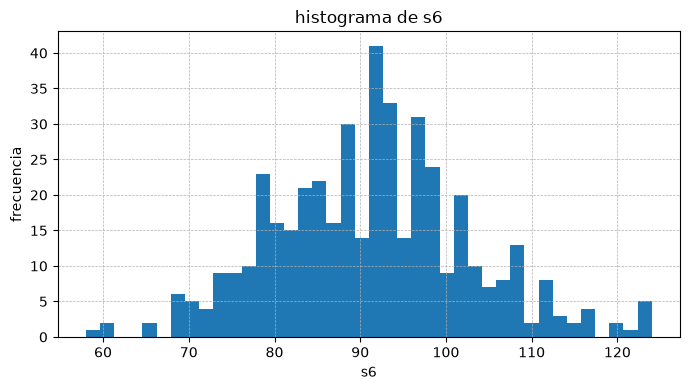

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


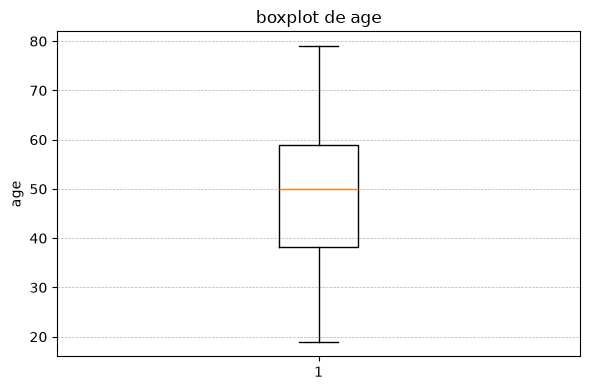

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


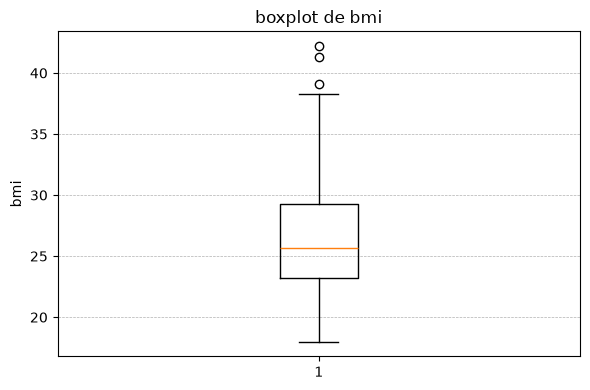

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


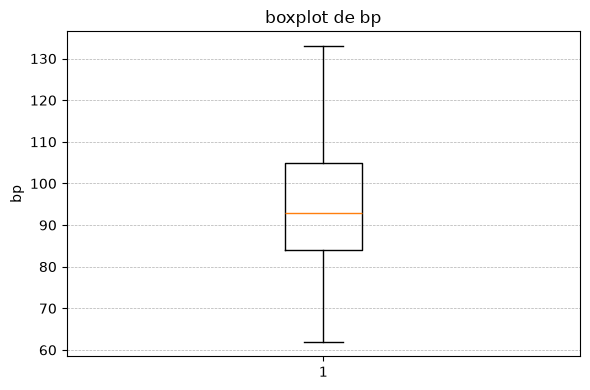

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


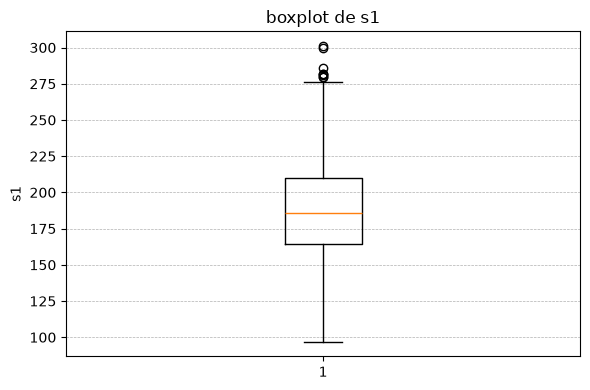

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


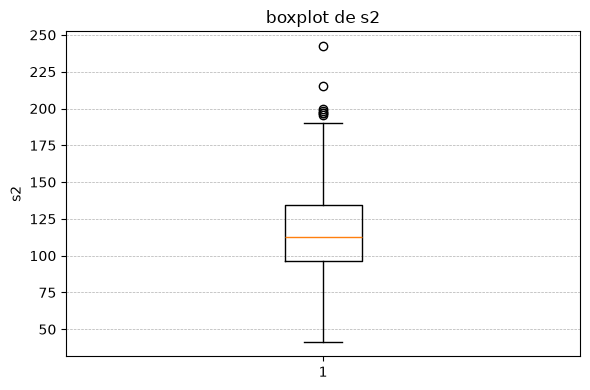

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


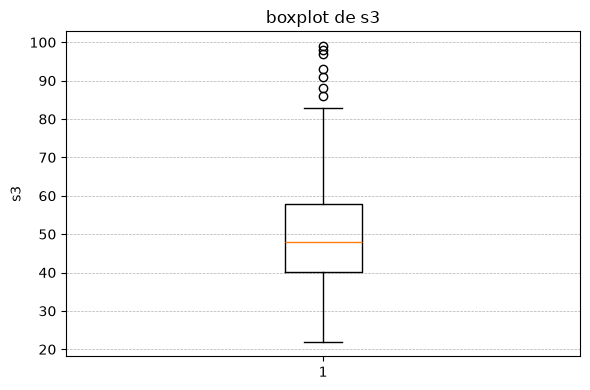

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


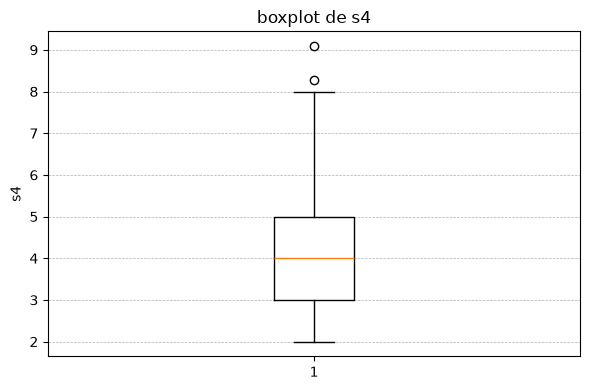

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


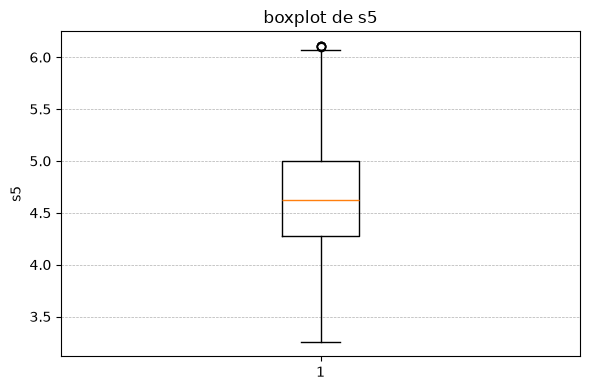

/tmp/ipykernel_24886/1957895106.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].values, vert=True, label=[c.lower()])


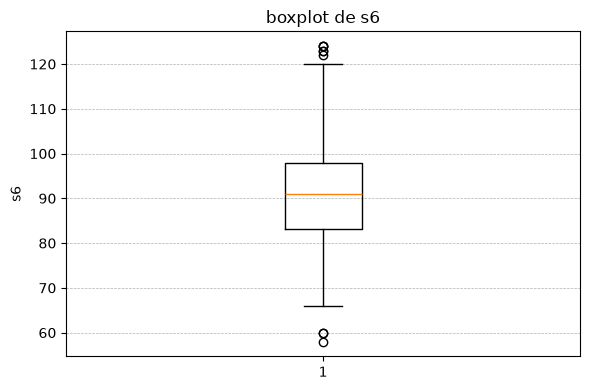

In [7]:
cols = ['age','bmi','bp','s1','s2','s3','s4','s5','s6']

for c in cols:
    plt.figure(figsize=(7,4))
    df[c].hist(bins=40)
    plt.title(f"histograma de {c}")
    plt.xlabel(c.lower())
    plt.ylabel("frecuencia")
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

for c in cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[c].values, vert=True, label=[c.lower()])
    plt.title(f"boxplot de {c}")
    plt.ylabel(c.lower())
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


## Detección de outliers con regla iqr
contamos valores atípicos por variable para decidir transformaciones o robustecer métricas.


In [ ]:
import numpy as np, pandas as pd
def iqr_outliers_count(series: pd.Series):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    '''0. Now I understand why the lower or higher whiskers can be assymetrical! It is 
    not simply 1.5, you subtract the lower interquartil and add the higher one. '''
    mask = (series < low) | (series > high)
    return mask.sum(), low, high

results = []
for col in df.columns:
    if col == 'target_disease_progression':
        continue
    n_out, low, high = iqr_outliers_count(df[col])
    results.append((col, n_out))

out_df = pd.DataFrame(results, columns=["variable","outliers_iqr"]).sort_values("outliers_iqr", ascending=False)
out_df


,variable,outliers_iqr
9,s6,9
4,s1,8
6,s3,7
5,s2,7
8,s5,4
2,bmi,3
7,s4,2
0,age,0
1,sex,0
3,bp,0


## Correlaciones
calculamos la matriz de correlación de pearson entre características y con la variable objetivo.


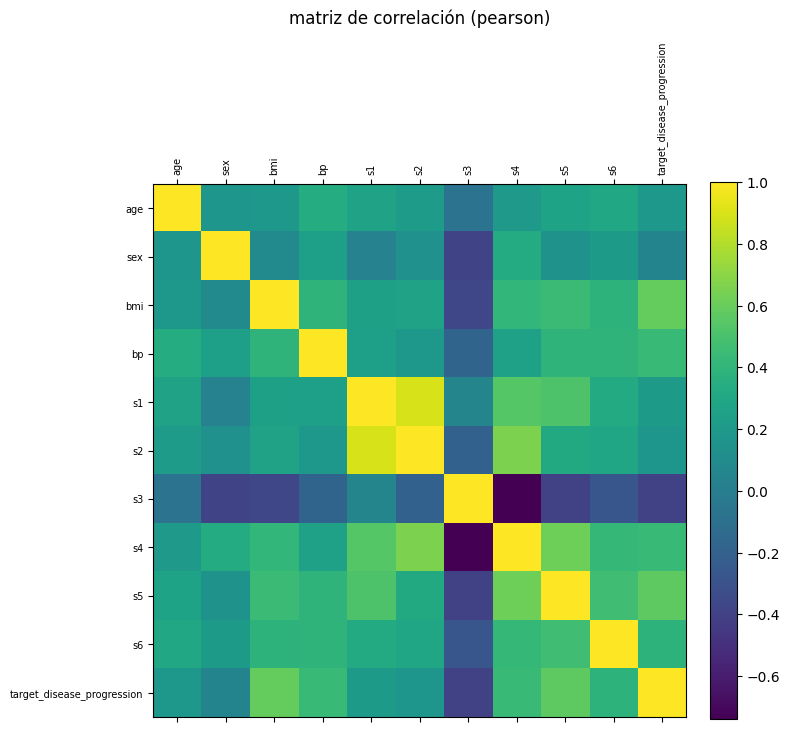

In [ ]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, cmap='viridis')
plt.title("matriz de correlación (pearson)", pad=12)
plt.xticks(range(len(corr.columns)), [c.lower() for c in corr.columns], rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), [c.lower() for c in corr.columns], fontsize=7)
fig.colorbar(cax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



## Relaciones bivariadas con la variable objetivo
graficamos pares de variables con mayor correlación con el objetivo para observar tendencias.


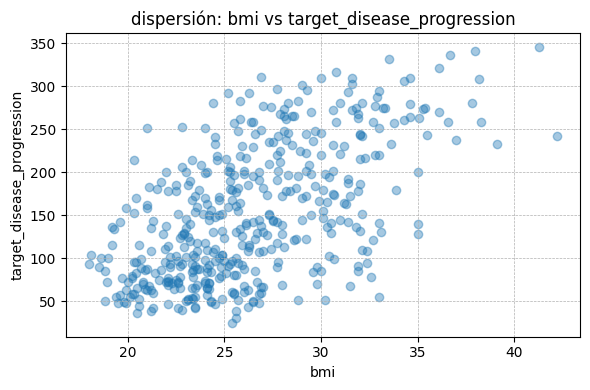

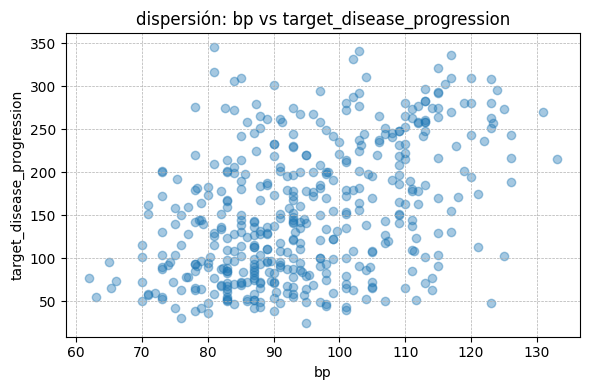

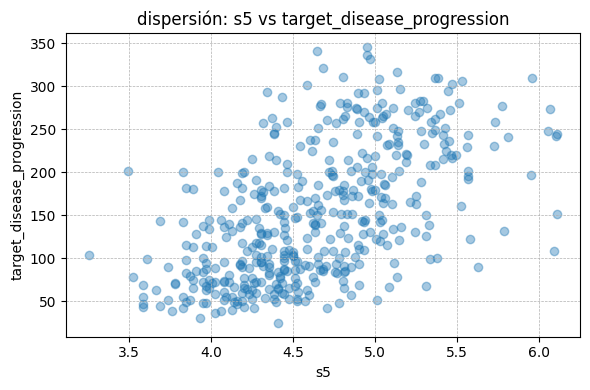

In [ ]:
pairs_to_plot = [
    ("bmi", "target_disease_progression"),
    ("bp", "target_disease_progression"),
    ("s5", "target_disease_progression")
]

for x, y in pairs_to_plot:
    plt.figure(figsize=(6,4))
    plt.scatter(df[x], df[y], alpha=0.4)
    plt.xlabel(x.lower())
    plt.ylabel(y.lower())
    plt.title(f"dispersión: {x} vs {y}")
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


## Preparar datos para modelado (opcional)
dejamos una partición de entrenamiento/prueba y un escalado estándar para usar en la siguiente unidad.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target_disease_progression']).values
y = df['target_disease_progression'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("formas → X_train:", X_train.shape, "| X_test:", X_test.shape)


formas → X_train: (353, 10) | X_test: (89, 10)


### Por completar
1) repetir la sección de **visualizaciones univariadas** con al menos 4 variables distintas a las usadas y **describir en 3–5 oraciones** los hallazgos.  
2) listar las **tres** variables con mayor correlación (en valor absoluto) con `target_disease_progression` y proponer una hipótesis breve sobre su relación.  
3) detectar variables con **> 50 outliers** bajo la regla iqr y proponer **una** estrategia para tratarlos (transformación log, winsorización, estandarización robusta).  
4) crear **dos** gráficos de dispersión adicionales con `alpha=0.4` que te ayuden a explicar la variabilidad del objetivo y escribe **dos** conclusiones.  
5) redactar **un resumen de 8–10 oraciones** con las conclusiones del eda y **dos** recomendaciones para el preprocesamiento antes del modelado.
